# Coil-driven Type1 CLN on a conducting washer

**C2 candidate: independent scientific review pending.** This notebook validates an energy-normalized CLN against its own finite-element model. It does not establish continuum accuracy or an independent full T–Omega formulation.

A closed azimuthal coil drives a washer inside a perfectly conducting cylindrical enclosure. The washer is multiply connected: its divergence-free insulated currents contain a topological loop channel in addition to curls. A–phi is the primary model. The A–T current-space control includes this loop, but shares the A magnetic inverse. The zero and positive real expansion points both use eight elements.

Generic cut, natural magnetic representative and minimum-Joule current APIs belong in Radia. The adapters used here are **temporary validation helpers** with that proposed API contract. Radia 5.2.3 does not expose the proposed API. F2 and a migration to a tested, version-pinned published Radia API remain open; the CLN ladders/evidence belong in CLN-mcp.


In [1]:
from pathlib import Path
import hashlib, json, math
import numpy as np
import matplotlib.pyplot as plt
root = Path.cwd()
if root.name == 'docs':
    root = root.parent
result = json.loads((root/'docs/data/c2_washer.json').read_text())
rep = json.loads((root/'docs/data/c2_representatives.json').read_text())
print(result['claim'])
print('Recorded runtime:', result['runtime']['radia'], result['runtime']['ngsolve'])


Same-mesh energy-normalized Type1 CLN; no continuum accuracy or independent T-Omega claim.
Recorded runtime: 5.2.3 6.2.2607


## Geometry, excitation and the full reference

The washer has radii 8/14 mm, thickness 3 mm and height interval 8.5–11.5 mm. Conductivity is $10^6$ S/m; permeability is $\mu_0$. The surrounding enclosure has radius 25 mm and height 20 mm. The closed coil occupies radii 18–21 mm and heights 5–7 mm. Its smooth azimuthal source is normalized by $\int J_\theta\,dr\,dz=1$ A. The source has no included winding resistance. Air and the source region have **zero conductivity**.

Tangential A is zero on the enclosure. A global gradient gauge is used; conductor phi has one constant gauge and natural zero normal current. The same-mesh full impedance is $Z(s)=s f^T(K+sM_c)^{-1}f$, where $M_c=M-C^TS^{-1}C$ eliminates phi. The solvable gradient gauge must not enter physical magnetic energy. The original blocks and field stage arrays are exported for independent review.


In [2]:
print('coarse tetrahedra / free A DOFs:', result['primary'][0]['ne'], result['primary'][0]['dofs'])
print('source gradient projection fraction:', result['primary'][0]['source_projection_fraction'])
print('loop and curl dimensions:', result['dual']['b1'], result['dual']['current_dimension'], result['dual']['curl_dimension'])
print('filled hole: loop channels / ordinary curl modes:', result['filled_hole']['loop_channels'], result['filled_hole']['curl_dimension'])


coarse tetrahedra / free A DOFs: 1644 1648
source gradient projection fraction: 3.894174144642673e-13
loop and curl dimensions: 1 40 39
filled hole: loop channels / ordinary curl modes: 0 71


## Physical Type1 recurrence and shifted elements

Write $H(s)=Z(s)/s$. With $A_0=K+s_0M_c$, the actual coil excitation initializes $a_0=A_0^{-1}f$. At each stage,

$\widehat L_n=a_n^TA_0a_n$, $e_n=e_{n-1}+a_n/\widehat L_n$, $R_n=(e_n^TM_ce_n)^{-1}$,

$a_{n+1}=a_n-R_nA_0^{-1}M_ce_n$, with $e_{-1}=0$.

Every field is copied before the next stage. Magnetic increments are orthogonal in the shifted energy metric and electric fields in the Joule metric. At a positive shift, $\widehat L$ combines magnetic energy and $s_0$ times Joule energy. These are shifted ladder elements; substituting $q=s-s_0$ is essential.

Type1 starts with a shunt inductive branch because $Z(0)=0$. Its input is $H=\widehat L_0\parallel[R_0/q+(\widehat L_1\parallel\cdots)]$. At $q=0$, $H(s_0)=\widehat L_0$, and $Z(s_0)=s_0\widehat L_0$. Eight-element contact is checked for **H coefficients q0 through q7**. At zero shift, multiplication by s makes the corresponding Z difference begin at order 9. This is a local approximation, not an all-frequency exact circuit.


In [3]:
for name, runs in [('A-phi', result['primary'][0]['runs']), ('A-T current control', result['dual']['runs'])]:
    for run in runs:
        print(name, 's0 =', f"{run['s0']:.6g}", 'orthogonality', f"{run['orthogonality']:.3g}")
        for stage, (ell, resistance) in enumerate(zip(run['elements'][::2], run['elements'][1::2])):
            print(f'  stage {stage}: Lhat = {ell*1e9:.6g} nH, R = {resistance:.6g} ohm')
        print('  max contact q0..q7:', f"{max(run['flux_taylor_relative'][:8]):.3g}")


A-phi s0 = 0 orthogonality 4.28e-14
  stage 0: Lhat = 35.6577 nH, R = 0.130143 ohm
  stage 1: Lhat = 472.519 nH, R = 0.96847 ohm
  stage 2: Lhat = 1376.69 nH, R = 10.0018 ohm
  stage 3: Lhat = 7564.25 nH, R = 27.3895 ohm
  max contact q0..q7: 3.32e-15
A-phi s0 = 62831.9 orthogonality 8.41e-15
  stage 0: Lhat = 35.1622 nH, R = 0.193222 ohm
  stage 1: Lhat = 529.081 nH, R = 1.29212 ohm
  stage 2: Lhat = 1708.11 nH, R = 12.6343 ohm
  stage 3: Lhat = 8460.21 nH, R = 36.5231 ohm
  max contact q0..q7: 3.85e-15
A-T current control s0 = 0 orthogonality 1.64e-11
  stage 0: Lhat = 35.6577 nH, R = 0.140032 ohm
  stage 1: Lhat = 556.05 nH, R = 5.24056 ohm
  stage 2: Lhat = 2094.59 nH, R = 127.969 ohm
  stage 3: Lhat = 19279.1 nH, R = 254.682 ohm
  max contact q0..q7: 1.04e-15
A-T current control s0 = 62831.9 orthogonality 1.68e-12
  stage 0: Lhat = 35.2063 nH, R = 0.217721 ohm
  stage 1: Lhat = 678.749 nH, R = 5.7081 ohm
  stage 2: Lhat = 2245.44 nH, R = 134.743 ohm
  stage 3: Lhat = 19547 nH, R =

## Topology controls and representative independence

The loop current minimizes Joule loss subject to divergence-free insulated current and unit cut flux. A unit-period magnetic generator is distinct from the resulting unit-flux current. For the washer, $R_{loop}=2\pi/[\sigma t\ln(r_o/r_i)]$ is an analytic resistance control. The coarse curved RT0 current space has finite discretization error.

Flux is sampled on radial cuts at 0 and pi/3; exported vectors and area weights allow independent integration. Filling the hole removes the topological channel while leaving ordinary curl currents. Omitting the loop on the original geometry clamps its cut flux to zero; it does **not** model the filled geometry.

The second representative is $h+\nabla\eta$ with a change equal to the original generator norm. Both natural scalar systems are separately assembled. The exports verify $b_2-b_1=-S\eta$. Separately constructed constrained currents agree, and all eight ladder elements agree at both shifts. A vertex-order change alone would not establish this control.


In [4]:
dual = result['dual']
print('cut flux samples:', [f'{x:.7g}' for x in dual['sampled_cut_flux']])
print('loop resistance:', f"{dual['loop_R']:.7g}", 'ohm; analytic error:', f"{100*dual['loop_R_error']:.4g}%")
print('representative norm change:', f"{rep['generator_relative_difference']:.6g}")
print('independent natural field gap:', f"{rep['field_relative_gap']:.3g}")
print('separately constructed current / element gaps:', dual['representative']['loop_relative_gap'], dual['representative']['element_relative_gaps'])
for cut in rep['cuts']:
    independently_integrated = np.sum(np.asarray(cut['J_A_per_m2']) @ cut['normal']) * cut['area_weight_m2']
    print('cut angle / integrated A:', f"{cut['angle']:.6g}", f'{independently_integrated:.7g}')


cut flux samples: ['1', '1.000002']
loop resistance: 0.003796342 ohm; analytic error: 1.437%
representative norm change: 1
independent natural field gap: 1.31e-13
separately constructed current / element gaps: 3.822698181149088e-14 [4.1520120674931604e-12, 4.618971871650501e-12]
cut angle / integrated A: 0 1
cut angle / integrated A: 1.0472 1.000002


## Full impedance can conceal loss and loop errors

The power table uses a 1 A RMS port: the Joule value equals Re Z. Unit peak phasors instead give half that average power. Magnetic quadratic forms used for circuit normalization omit the stored-energy factor 1/2.

The full impedance is largely inductive. Report Re Z, the Joule integral and the eddy increment $Z-sL_{coil}$ separately. The loop-omission control may strongly change the eddy contribution while barely changing full Z. No monotonicity of loss under loop omission is assumed. A–T/A–phi agreement at a fixed mesh is also not a continuum error estimate.


In [5]:
print('Hz | Re Z [ohm] | Joule [W at 1 A] | eddy increment | A-T/A-phi loss gap | omitted-loop eddy gap')
for row in dual['frequency']:
    print(f"{row['hz']:.0f} | {row['Z'][0]:.6g} | {row['joule']:.6g} | {complex(*row['eddy_increment']):.6g} | {100*row['Aphi_loss_gap']:.4g}% | {100*row['omitted_eddy_increment_relative']:.4g}%")


Hz | Re Z [ohm] | Joule [W at 1 A] | eddy increment | A-T/A-phi loss gap | omitted-loop eddy gap
1000 | 3.58198e-07 | 3.58198e-07 | 3.58198e-07-9.50986e-09j | 7.067% | 94.88%
10000 | 3.3438e-05 | 3.3438e-05 | 3.3438e-05-8.86117e-06j | 7.56% | 94.85%
100000 | 0.000507899 | 0.000507899 | 0.000507899-0.00115069j | 37.09% | 91.86%
1000000 | 0.0020577 | 0.0020577 | 0.0020577-0.0161853j | 13.59% | 62.22%


## Refinement: retain the unresolved accuracy gap

The axisymmetric r–z reference uses $A_\theta=r u$. It is first checked against a solid-cylinder Bessel solution with a sinusoidal axial source, derived in the supplied WLS. That is an analytic **limit check**, not an analytic solution of this washer/coil configuration. The washer reference then uses two increasing 2D meshes with the same PEC enclosure and source profile.

3D cases separate coil mesh refinement and magnetic polynomial enrichment. They do not resolve all conductor skin layers. Skin depths are 1.59 mm at 100 kHz and 0.50 mm at 1 MHz; the 3D conductor mesh is under-resolved. Quantitative gaps below are disclosed rather than converted into a continuum accuracy claim. In particular, small reduction error cannot repair coil inductance or loss discretization errors.


2D reference triangle / DOF counts: [(4660, 9220), (4356, 8612), (17724, 35248)]
maximum solid-cylinder analytic error: 7.071519032088667e-05
1644 tets, A order 0, coil h 6 mm DC self-L signed gap: -39.23% 1 MHz loss signed gap: 35.36%
4501 tets, A order 0, coil h 2 mm DC self-L signed gap: -29.92% 1 MHz loss signed gap: 15.66%
4501 tets, A order 2, coil h 2 mm DC self-L signed gap: -5.621% 1 MHz loss signed gap: 24.02%


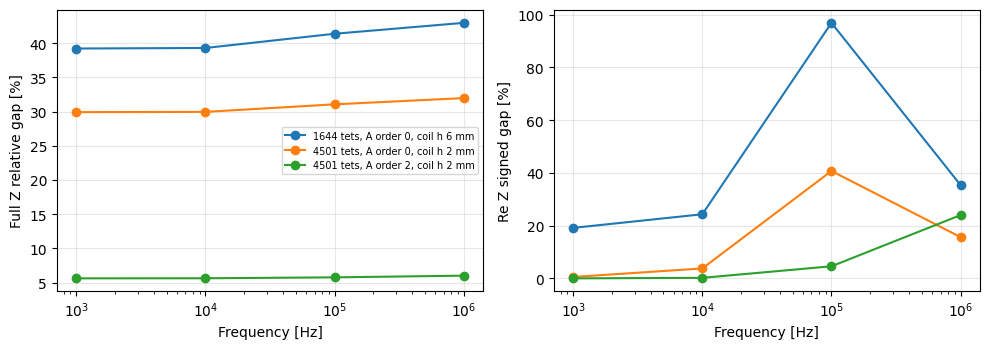

In [6]:
print('2D reference triangle / DOF counts:', [(x['triangles'], x['dofs']) for x in result['axisymmetric']])
print('maximum solid-cylinder analytic error:', max(x['relative_error'] for x in result['axisymmetric'][0]['frequency']))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for case in result['primary']:
    label = f"{case['ne']} tets, A order {case['a_order']}, coil h {1e3*case['coil_h']:g} mm"
    hz = [x['hz'] for x in case['axisymmetric_comparison']]
    axes[0].semilogx(hz, [100*x['full_Z_gap'] for x in case['axisymmetric_comparison']], 'o-', label=label)
    axes[1].semilogx(hz, [100*x['loss_signed_gap'] for x in case['axisymmetric_comparison']], 'o-', label=label)
    print(label, 'DC self-L signed gap:', f"{100*case['self_inductance_signed_gap']:.4g}%", '1 MHz loss signed gap:', f"{100*case['axisymmetric_comparison'][-1]['loss_signed_gap']:.4g}%")
axes[0].set_ylabel('Full Z relative gap [%]'); axes[1].set_ylabel('Re Z signed gap [%]')
for ax in axes:
    ax.set_xlabel('Frequency [Hz]'); ax.grid(True, alpha=.3)
axes[0].legend(fontsize=7); fig.tight_layout(); plt.show()


## Reduction error on the named coarse mesh

The following curves are compared with the full model on the **1644-tetrahedron coarse mesh**, separately for primary A–phi and the current-space A–T control. They are not comparisons with the 2D reference. The shift changes the local approximation region and every ladder element.


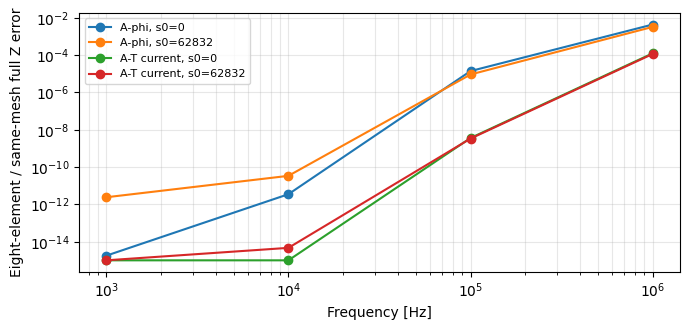

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.4))
for name, runs in [('A-phi', result['primary'][0]['runs']), ('A-T current', dual['runs'])]:
    for run in runs:
        ax.loglog([x['hz'] for x in run['frequency']], [max(x['reduction_error'], 1e-15) for x in run['frequency']], 'o-', label=f"{name}, s0={run['s0']:.5g}")
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('Eight-element / same-mesh full Z error')
ax.grid(True, which='both', alpha=.3); ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## Reproduction, dependency and references

Native reproduction (NGSolve 6.2.2607, Radia 5.2.3, NumPy/SciPy/mpmath):

```
python validation/cln3d/c2_study.py
python validation/cln3d/c2_representatives.py
python validation/cln3d/c2_rank_controls.py
wolframscript -file validation/cln3d/derive_c2_solid_cylinder.wls
python validation/validate_c2_washer.py
```

`--coarse-only` is a pilot option, not a replacement for the recorded refinement cohort. Native calculations can be costly. The CI validator requires only NumPy and original exported matrices; it checks each contact coefficient and rejects a corrupted tail coefficient. Stored refined native cases are evidence, not CI FEM reruns. Source identities and native versions are recorded. The shared ladder dependency permits LF/CRLF checkout conversion only; owned producers have fixed LF bytes. Production quotient-threshold controls retain the same four null directions at 1e-10, 1e-11 and 1e-12. Generic API extraction F2, migration/version pin and the independent full T–Omega comparison remain open in [review status](REVIEW_STATUS.md).

[Pellikka, Suuriniemi, Kettunen and Geuzaine, *Homology and Cohomology Computation in Finite Element Modeling*, SIAM J. Sci. Comput. 35, B1195–B1214 (2013)](https://epubs.siam.org/doi/10.1137/130906556) discusses finite-element cohomology and parameter coupling. [Stockrahm, Lahtinen, Kangas and Kotiuga, *Cuts for 3-D magnetic scalar potentials* (2019)](https://arxiv.org/abs/1902.01124) discusses magnetic scalar cuts. [Kameari et al., *Cauer Ladder Network Representation of Eddy-Current Fields for Model Order Reduction Using Finite-Element Method*, Compumag 2017](https://www.compumag.org/Proceedings/2017_Daejeon/papers/%5BPA-M1-2%5D_52.pdf) describes field-based CLN reduction. The shifted coil/washer experiments here are self-authored numerical examples with the limits stated above.
